In [1]:
!pip install nltk

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from nltk.corpus import stopwords #CHANGE: added stopwords

os.makedirs('./results', exist_ok=True)

with open('./brown_100.txt', 'r') as file_:
    corpus = file_.read()

def write_freqs(list_: list, filename: str) -> None:
    with open(f'./results/{filename}.txt', 'w') as file_:
        for x in list_:
            print(x)
        file_.write('\n'.join([' '.join(x[0]) + ' | ' + str(x[1]) for x in list_]))

## N-Gram Language Modeling
In the second assignment, you will implement an **n-gram language model** that processes input text to generate, analyze, and calculate the probabilities of sequences of `n` words (n-grams). This model will tokenize text, create n-grams, and compute their frequencies and probabilities, returning the most frequent n-grams in the text.

1. **Tokenization**: Convert the input text into a list of words (tokens).
2. **N-gram Generation**: Create sequences of `n` tokens from the text, treating each sentence independently with the inclusion of start (`<s>`) and end (`</s>`) markers.
3. **Frequency Counting**: Count how many times each n-gram appears in the text.
4. **Probability Calculation**: Compute the probabilities of each n-gram based on its frequency and add alpha smoothing to improve generalization of items.
5. **Most Frequent N-grams**: Return the most frequent n-grams along with their probabilities, helping to identify common patterns in the text.

In [3]:
from collections import Counter, defaultdict # You may import more from collections if needed
from nltk.tokenize import word_tokenize
from typing import Union
import string
import re

class NGramModel:
    def __init__(self, text, n, alpha=0.0):
        """
        Initialize the NGramModel with text and the value of n.
        """
        self.text = text
        self.n = n
        self.alpha = alpha  # Alpha value for additive smoothing
        self.ngrams: Union[list,dict] = []
        #self.ngrams= {} #changed this
        self.probabilities = {}
        self.vocab = set()
    
    def remove_punctuation(self, keep_symbols="</>"):
        to_remove = "".join(ch for ch in string.punctuation if ch not in keep_symbols)
        self.text = re.sub(f"[{re.escape(to_remove)}]", "", self.text)

        return text


    def tokenize(self, drop_stopwords= False) -> None:
        """
        Tokenize the text into words. 
        Fill in the code to split the text into a list of words.
        """

        self.remove_punctuation() # remove punctuation

        # lowercase
        self.text = self.text.lower()
        tokens = self.text.split()
        if drop_stopwords == True:
            en_stopwords = set(stopwords.words('english'))
            tokens = [word for word in tokens 
                    if len(word) > 1 and word not in en_stopwords] # for removing stopwords and one letter words

        return tokens

    def generate_ngrams(self, tokens: list, multiple_sentence=True ) -> dict:
        """
        Generate n-grams from the list of tokens.
        Fill in the code to create n-grams.
        Make sure to treat each sentence independently, include the <s> and </s> tokens.
        """
        # Split sentence if tokens is a 2d list
        if multiple_sentence:
            sentences = []
            sent = []
            for tok in tokens:
                sent.append(tok)
                if tok == '</s>':
                    sentences.append(sent)
                    sent = []

            for sentence in sentences:
                for i in range(len(sentence)-self.n+1):
                    # extract n-gram
                    self.ngrams.append(tuple(sentence[i: i+self.n]))
                    self.vocab.update(tuple(sentence[i: i+self.n]))
        else:
            # in case tokens represent only one sentence
            for i in range(len(tokens)-self.n+1):
                self.ngrams.append(tuple(tokens[i: i+self.n]))
                self.vocab.update(tuple(tokens[i: i+self.n]))
        return self.ngrams 
    

    def count_frequencies(self) -> None:
        """
        Count the frequencies of each n-gram.
        Fill in the code to count n-gram occurrences.
        """
        self.ngrams = dict(Counter(self.ngrams))

               


    def calculate_probabilities(self) -> None:
        """
        Calculate probabilities of each n-gram based on its frequency. Add alpha smoothing separately.
        """
        # calculate the total number of items in vocab
        total_count = sum(self.ngrams.values()) 
        vocab_size = len(self.vocab)
        if self.alpha != 0.0:
            self.probabilities = {k: (v+self.alpha)/(total_count + self.alpha*vocab_size) for k, v in self.ngrams.items()}
        else:  
            self.probabilities = {k: v/total_count for k, v in self.ngrams.items()}
        


    def most_frequent_ngrams(self, top_n: int = 10) -> list:
        """
        Return the most frequent n-grams and their probabilities.
        """
        sorted_grams = list(sorted(self.probabilities.items(), key=lambda x:x[1], reverse=True))
        
        return sorted_grams[:top_n]

# Testing the model with an example
text = "This is a simple example to demonstrate how n-grams work in this assignment." #Faster than running the full corpus
n = 1  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(text, n)

tokens = model.tokenize()
print(tokens)
ngrams = model.generate_ngrams(tokens, multiple_sentence=False)
model.count_frequencies()
model.calculate_probabilities()

# Print the most frequent n-grams
print(model.most_frequent_ngrams(10))

['this', 'is', 'a', 'simple', 'example', 'to', 'demonstrate', 'how', 'ngrams', 'work', 'in', 'this', 'assignment']
[(('this',), 0.15384615384615385), (('is',), 0.07692307692307693), (('a',), 0.07692307692307693), (('simple',), 0.07692307692307693), (('example',), 0.07692307692307693), (('to',), 0.07692307692307693), (('demonstrate',), 0.07692307692307693), (('how',), 0.07692307692307693), (('ngrams',), 0.07692307692307693), (('work',), 0.07692307692307693)]


### Unigrams

In this section, we apply the `NGramModel` to our corpus. The model can be configured to generate unigrams, bigrams, or trigrams by adjusting the value of `n`. After tokenizing the text and generating the n-grams, the model counts the occurrences of each n-gram and calculates their probabilities. The most frequent n-grams are then written to an output file.

By adjusting the n-gram size, we can analyze different levels of word dependencies in the text, providing insights into common word sequences and patterns.  

The code below will generate unigrams when the NGramModel is implemented correctly

In [4]:
n = 1  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

model.most_frequent_ngrams(10)
write_freqs(model.most_frequent_ngrams(10), 'unigrams')

(('the',), 0.07062019013128112)
(('<s>',), 0.04526935264825713)
(('</s>',), 0.04526935264825713)
(('of',), 0.030330466274332276)
(('to',), 0.02489814395654142)
(('a',), 0.02444545043005885)
(('in',), 0.01810774105930285)
(('and',), 0.01810774105930285)
(('that',), 0.012675418741511997)
(('said',), 0.010864644635581712)


### Bigrams
Bigrams allow us to explore word pairs and their relationships, providing insight into common word combinations and phrase structures within the corpus.  
The code below will generate bigrams when the NGramModel is implemented correctly.

In [5]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams')


(('<s>', 'the'), 0.012802275960170697)
(('in', 'the'), 0.007586533902323376)
(('of', 'the'), 0.006638217164532954)
(('the', 'jury'), 0.006164058795637743)
(('jury', 'said'), 0.003793266951161688)
(('the', 'fulton'), 0.002844950213371266)
(('fulton', 'county'), 0.002844950213371266)
(('the', 'election'), 0.002844950213371266)
(('<s>', 'it'), 0.002844950213371266)
(('at', 'the'), 0.002844950213371266)


### Trigrams
Trigrams capture three-word sequences, providing a deeper understanding of longer word dependencies and commonly occurring phrases within the text.  
The code below will generate trigrams when the NGramModel is implemented correctly

In [6]:
n = 3  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'trigrams')

(('the', 'jury', 'said'), 0.003484320557491289)
(('<s>', 'the', 'jury'), 0.0029865604778496766)
(('the', 'fulton', 'county'), 0.0014932802389248383)
(('jury', 'said', 'it'), 0.0014932802389248383)
(('to', 'make', 'the'), 0.0014932802389248383)
(('is', 'expected', 'to'), 0.0014932802389248383)
(('million', 'worth', 'of'), 0.0014932802389248383)
(('at', 'the', 'polls'), 0.0014932802389248383)
(('that', 'the', 'city'), 0.0009955201592832255)
(('the', 'election', 'was'), 0.0009955201592832255)


### Smoothing
Below, we generate **bigrams** with **smoothing** applied by setting `n = 2` and including a smoothing parameter `alpha = 1.0`. Smoothing is useful in language models to handle unseen n-grams by assigning a small probability to them. The model tokenizes the text, generates bigrams, counts their frequencies, and calculates smoothed probabilities. The most frequent bigrams are then written to an output file.





In [7]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n, alpha=1.0)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams_smoothed')

(('<s>', 'the'), 0.009615384615384616)
(('in', 'the'), 0.005837912087912088)
(('of', 'the'), 0.005151098901098901)
(('the', 'jury'), 0.004807692307692308)
(('jury', 'said'), 0.0030906593406593405)
(('the', 'fulton'), 0.002403846153846154)
(('fulton', 'county'), 0.002403846153846154)
(('the', 'election'), 0.002403846153846154)
(('<s>', 'it'), 0.002403846153846154)
(('at', 'the'), 0.002403846153846154)


### Generating Text
In this example, we generate text using the **bigrams** model by providing a starting **prompt** (e.g., "the jury"). The `generate_text` function creates a sequence of words based on the trained bigram model, starting from the provided prompt and continuing based on the probabilities of the next words.

After tokenizing the corpus, generating bigrams, and calculating their frequencies and probabilities, the model uses these learned probabilities to generate text. The generated output is then written to a file.

Text generation with n-grams helps illustrate how language models can predict word sequences, allowing us to create new sentences that follow similar patterns found in the original text.

In [8]:
def generate_text(model: NGramModel, n: int, prompt: str, max_token: int = 100) -> str:
    """Generate text greedily using conditional n-gram probabilities."""

    tokens = prompt.lower().split()

    for _ in range(max_token):
        if n == 1:
            # no history for unigram
            candidates = [(gram[0], count) for gram, count in model.ngrams.items()]
        else:
            # Bigram or trigram model
            history = tuple(tokens[-(n - 1):])
            candidates = [
                (gram[-1], count)
                for gram, count in model.ngrams.items()
                if gram[:-1] == history
            ]

        # Stop if no continuation is available for the current history.
        if not candidates:
            break

        words = [w for w, _ in candidates]
        weights = np.array([c for _, c in candidates])
        probs = weights / weights.sum()

        # Probabilistic decoding: sample next token by learned distribution.
        next_token = rng.choice(words, p=probs)

        if next_token == '</s>':
            tokens.append('.')
            break

        tokens.append(next_token)

    return ' '.join(tokens)


n = 2  
rng = np.random.default_rng(2345)
model = NGramModel(corpus, n)
tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()
generated_text = generate_text(model, 2, 'the jury')
print(generated_text)
with open(f'./results/generated_bigrams.txt', 'w') as file_:
    file_.write(generated_text)

the jury had been expected to work with a gun and operation of additional deputies .


### Model Evaluation (optional)

The models are compared based on **perplexity** metric. 

Here, we evaluated three models, such as unigram, bigram, and trigram, in their ability of generating setences. For each model, the conditional probability of a word given its history is modified to match with its model's characteristics. The perflexity is calculated on one synthetic sentence for each model.

 In computing the length of a sequence, the special symbols in the sentence are equally treated as normal tokens in a sequence. In other words, the length of the sequence is equal to the number of tokens plus 1, for the end symbol.


In [9]:
import math

In [10]:
def calculate_perplexity(model: NGramModel, n: int = 2, test_set: list[str] = None) -> float:
    """
    Calculate perplexity using conditional probabilities from n-gram counts.
    """
    alpha = model.alpha
    vocab_size = len(model.vocab)
    total_count = sum(model.ngrams.values())

    # prepare the denominator
    history_counts = defaultdict(int)
    if n > 1:
        for ngram, count in model.ngrams.items():
            history_counts[ngram[:-1]] += count

    total_log_prob = 0.0
    total_ngrams = 0
    epsilon = 1e-10

    for sent in test_set:

        tokens = sent.lower().split()
        limit = len(tokens) - n + 1

        for i in range(limit):

            ngram = tuple(tokens[i:i + n])
            count = model.ngrams.get(ngram, 0)

            if n == 1:
                denominator = total_count + alpha * vocab_size
            else:
                history = ngram[:-1]
                denominator = history_counts[history] + alpha * vocab_size 

            if denominator == 0:
                probability = epsilon
            else:
                probability = (count + alpha) / denominator if alpha > 0 else count / denominator
                probability = max(probability, epsilon) # smooth

            total_log_prob += math.log(probability)
            total_ngrams += 1


    return math.exp(-total_log_prob / total_ngrams)

In [11]:
test_set = [
    '<s> The jury said the election was conducted in a calm manner </s>',
    '<s> The mayor said the city should improve the road and airport </s>',
    '<s> The state welfare department should receive federal funds </s>',
    '<s> The legislature approved the highway bond issue Monday </s>',
    '<s> The new school superintendent received votes in the county election </s>',
]

for i in range(0,3):
    n = i + 1

    # train model 
    model = NGramModel(corpus, n, alpha=1.0)
    tokens = model.tokenize()
    ngrams = model.generate_ngrams(tokens)
    model.count_frequencies()
    model.calculate_probabilities()


    # test model
    perplexity_score = calculate_perplexity(model,
                                            n=n,
                                            test_set=test_set)
    
    match_title = {1:"Unigram",
                   2:"Bigram", 
                   3:"Trigram"}
    
    print(f"{match_title[n]} model | Perplexity: {perplexity_score:.2f} .")




Unigram model | Perplexity: 155.42 .
Bigram model | Perplexity: 320.78 .
Trigram model | Perplexity: 626.68 .


## Word Vectors
Note: This part of the notebook was originally written for a corpus based on movie reviews from IMDb, based on a Stanford course (https://web.stanford.edu/class/cs224n/). Part of your task is to adapt this portion of the notebook to the corpora used in the previous parts of the assignment: namely, the Brown Corpus and the Indian Language Corpus. You will need to access these corpora from NLTK and perform all functions for both corpora. Note down any updates in the code in your comments.

### Count based W2V
In this section, we use the previously trained **n-gram model** to calculate a **co-occurrence matrix**. A co-occurrence matrix shows how often words appear together within a specific context (in this case, bigrams), providing insights into word relationships in the corpus.

Steps:
1. **Tokenization and N-gram Generation**: We first tokenize the text and generate bigrams using the `NGramModel`.
2. **Vocabulary and Indexing**: The vocabulary is created from the unique tokens, and a word-to-index mapping is established.
3. **Co-occurrence Matrix**: Using the generated n-grams, we compute the co-occurrence matrix, where each entry represents how often two words occur together within the bigrams.

The co-occurrence matrix provides a numerical representation of word relationships, which is useful for tasks like word embeddings, semantic analysis, and understanding word associations.

In [12]:
#CHANGE: added the import of brown corpus and indian lanugage corpus, due to computational limitaties we selected only two genres from the brown corpus: "romance" and "humorous"
import nltk
from nltk.corpus import brown
from nltk.corpus import indian
import os

#download the corpuses
nltk.download('brown')
nltk.download('indian')

#brown corpus
#corpus_brown = ' '.join(brown.words(categories=['romance', 'humor']))
brown_sents = brown.sents(categories=['romance', 'humor'])
corpus_brown = ' '.join(
    '<s> ' + ' '.join(sent) + ' </s>'
    for sent in brown_sents
)

#load the corpus ILM and add end sentence tags
#corpus_ILM = ' '.join(indian.words())
indian_sents = indian.sents('hindi.pos')
corpus_ilm = ' '.join(
    '<s> ' + ' '.join(sent) + ' </s>'
    for sent in indian_sents
)

print(corpus_brown)
print(corpus_ilm)

[nltk_data] Downloading package brown to
[nltk_data]     /Users/alicjadorobis/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package indian to
[nltk_data]     /Users/alicjadorobis/nltk_data...
[nltk_data]   Package indian is already up-to-date!


<s> They neither liked nor disliked the Old Man . </s> <s> To them he could have been the broken bell in the church tower which rang before and after Mass , and at noon , and at six each evening -- its tone , repetitive , monotonous , never breaking the boredom of the streets . </s> <s> The Old Man was unimportant . </s> <s> Yet if he were not there , they would have missed him , as they would have missed the sounds of bees buzzing against the screen door in early June ; ; </s> <s> or the smell of thick tomato paste -- the ripe smell that was both sweet and sour -- rising up from aluminum trays wrapped in fly-dotted cheesecloth . </s> <s> Or the surging whirling sounds of bats at night , when their black bodies dived into the blackness above and below the amber street lights . </s> <s> Or the bay of female dogs in heat . </s> <s> They never called him by name , although he had one . </s> <s> Filippo Rossi , that's what he was called in the old country ; ; </s> <s> but here he was just 

In [13]:
def create_co_matrix(ngrams: list, vocab_size: int, word_to_index: dict) -> np.ndarray:
    #CHANGE: implemetned the co_matrix function
    co_matrix = np.zeros((vocab_size,vocab_size)) #intialise an empty matrix
    for ngram, count in ngrams.items():
        context, target = ngram[0], ngram[-1]   # first and last token
        if context not in word_to_index or target not in word_to_index:
            continue                            # skip <s> and </s>
        co_matrix[word_to_index[context], word_to_index[target]] += count
    return co_matrix


In [14]:
# Since we already have a working ngram model, for the next part we can use the ngrams to calculate the co-occurences.
# example using the combined Brown text
model_brown = NGramModel(corpus_brown, 2)
tokens_brown = model_brown.tokenize(drop_stopwords=True)
ngrams_brown = model_brown.generate_ngrams(tokens_brown)
model_brown.count_frequencies()
model_brown.ngrams
ngrams_brown=model_brown.ngrams


# example using the ILM text
model_ilm = NGramModel(corpus_ilm, 2)
tokens_ilm = model_ilm.tokenize(drop_stopwords=True)
ngrams_ilm = model_ilm.generate_ngrams(tokens_ilm)
model_ilm.count_frequencies()
model_ilm.ngrams
ngrams_ilm=model_ilm.ngrams

In [15]:
'''# 1. Sort the dictionary items by count (the second element in the tuple)
sorted_ngrams = sorted(ngrams_brown.items(), key=lambda item: item[1], reverse=True)

# 2. Get the top 10 most frequent bigrams
top_10 = sorted_ngrams[:200]

# 3. Print them clearly
print("Top 10 most frequent bigrams:")
for ngram, count in top_10:
    print(f"{ngram[0]} {ngram[1]}: {count}")'''

'# 1. Sort the dictionary items by count (the second element in the tuple)\nsorted_ngrams = sorted(ngrams_brown.items(), key=lambda item: item[1], reverse=True)\n\n# 2. Get the top 10 most frequent bigrams\ntop_10 = sorted_ngrams[:200]\n\n# 3. Print them clearly\nprint("Top 10 most frequent bigrams:")\nfor ngram, count in top_10:\n    print(f"{ngram[0]} {ngram[1]}: {count}")'

With the code below you can verify if the co-occurence works

In [16]:
vocab_brown = sorted(list(set(tokens_brown)))
vocab_size_brown = len(vocab_brown)
# Create a word-to-index mapping
word_to_index_brown = {word: idx for idx, word in enumerate(vocab_brown)}

# Generate the co-occurrence matrix for brown
co_matrix_brown = create_co_matrix(ngrams_brown, vocab_size_brown, word_to_index_brown)

print("Brown Corpus Statistics")
print(f"Vocabulary Size: {vocab_size_brown}")
print(f"Matrix Shape:    {co_matrix_brown.shape}")
print(f"Non-zero counts: {np.count_nonzero(co_matrix_brown)}")

Brown Corpus Statistics
Vocabulary Size: 10080
Matrix Shape:    (10080, 10080)
Non-zero counts: 35865


In [17]:
# vocabulary and mapping for ILM
vocab_ilm = sorted(list(set(tokens_ilm)))
vocab_size_ilm = len(vocab_ilm)
# Create a word-to-index mapping
word_to_index_ilm = {word: idx for idx, word in enumerate(vocab_ilm)}

# Generate the co-occurrence matrix for ILM
co_matrix_ilm = create_co_matrix(ngrams_ilm, vocab_size_ilm, word_to_index_ilm)

print("ILM Corpus Statistics")
print(f"Vocabulary Size: {vocab_size_ilm}")
print(f"Matrix Shape:    {co_matrix_ilm.shape}")
print(f"Non-zero counts: {np.count_nonzero(co_matrix_ilm)}")

ILM Corpus Statistics
Vocabulary Size: 2138
Matrix Shape:    (2138, 2138)
Non-zero counts: 6156


In [18]:
def check_co_occurrence(word1, word2, co_matrix, word_to_index):
    """
    Print the co-occurrence count for a specific word pair.
    """
    if word1 not in word_to_index or word2 not in word_to_index:
        print(f"One or both words '{word1}' and '{word2}' are not in the vocabulary.")
        return
    index1 = word_to_index[word1]
    index2 = word_to_index[word2]
    co_count = co_matrix[index1][index2]
    print(f"Co-occurrence count for '{word1}' and '{word2}': {co_count}")


check_co_occurrence('old', 'man', co_matrix_brown, word_to_index_brown)

#CHANGE: from "cat" to among as cat does not appear in the bronw_100.txt
check_co_occurrence('neither', 'liked', co_matrix_brown, word_to_index_brown) 

#note: check co-occurrences of word pairs relevant to your corpora, commenting why these pairs are interesting

Co-occurrence count for 'old' and 'man': 27.0
Co-occurrence count for 'neither' and 'liked': 1.0


Here we are checking for pairs that we saw in the printed text to see if the model is working correctly on the brown corpus.

In this part, we reduce the dimensionality of the **co-occurrence matrix** using **Singular Value Decomposition (SVD)**. This technique helps in extracting the most important features from the matrix, making it easier to visualize and interpret the relationships between words.

Steps:
1. **Singular Value Decomposition (SVD)**: The co-occurrence matrix is decomposed into three matrices: \( M = U \cdot \Sigma \cdot V^T \).
2. **Dimensionality Reduction**: We retain only the top `k` components (default is 2) from the SVD, effectively reducing the dimensionality of the matrix.
3. **Reduced Matrix**: The reduced matrix retains the most important semantic information and can be used for tasks such as **word embedding visualization** or **semantic similarity analysis**.

Dimensionality reduction allows us to capture the essence of word relationships in fewer dimensions, making it more efficient to process and visualize the data.

In [ ]:
def reduce_to_k_dim(M, k=2):
    # 1. SVD
    U, singular, V_trans = np.linalg.svd(M, full_matrices=False) 
    print(f"First singular value: {singular[0]:.2f}")
    print(f"Second singular value: {singular[1]:.2f}")
    
    # 2. dimensionality reduction - keep only top k components
    U_k = U[:, :k] # all rows, top k columns
    singular_k = singular[:k] #top k rows
    V_k = V_trans[:k, :] #top k rows and all columns
    
    # 3. reconstruct the reduced matrix - product of reduced U,s
    M_reduced = U_k @ np.diag(singular_k) # @ V_k is not neeeded as we do not reconstruct

    M_reduced[np.all(M_reduced == 0, axis=1)] = 1e-9 #CHANGE: adding a tiny error to avoid division by 0 in the GloVe
    return M_reduced


#check on 3D array
X = np.array([[4, 3, 3], [4, 5, 6], [5, 2, 6]])
print(X)
reduced_X = reduce_to_k_dim(X)
print(reduced_X)


[[4 3 3]
 [4 5 6]
 [5 2 6]]
First singular value: 13.01
Second singular value: 2.19
[[-5.69404336 -0.33578071]
 [-8.65266565 -1.33444798]
 [-7.87588071  1.70882249]]


In [20]:
#CHANGE: as the custom function is quite inefcient fro large datasets such as two genres from the brown corpus, we also use the ready TruncatedSVD
# TruncatedSVD is much faster as it does not coclaute all singular values befor slicing them
from sklearn.decomposition import TruncatedSVD
def reduce_to_k_dim_fast(M, k=2):
    
    svd = TruncatedSVD(n_components=k, n_iter=10, random_state=42)
    return svd.fit_transform(M)

In this final part, we visualize the reduced word embeddings in **2D space**. After reducing the dimensionality of the co-occurrence matrix using SVD, we plot the embeddings for each word to observe their relationships in a low-dimensional space.

Steps:
1. **Plotting the Embeddings**: Each word from the vocabulary is plotted based on its 2D coordinates from the reduced matrix.
2. **Visualization**: The scatter plot allows us to see how words cluster together or relate to each other based on co-occurrences in the text. Words with similar contexts should appear closer to each other in the plot.
3. **Interpretation**: By looking at the 2D plot, we can analyze word similarities, relationships, and clusters formed by words that often occur together.

This visualization is a useful tool for understanding the structure of word embeddings and the relationships between words in the corpus.







In [21]:
#CHANGE: create the function
def plot_embeddings(M:np.array,vocab:list):
    plt.figure(figsize=(12, 10))
    plt.scatter(M[:, 0], M[:, 1], c = 'blue',
              marker = '.',
              label = vocab)
    for i, txt in enumerate(vocab):
        plt.annotate(txt, (M[:, 0][i],
                        M[: , 1][i]),
                    xytext = (-5, 5),
                    textcoords = ('offset points'))
    plt.title("Word Embeddings (SVD reduced)")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    

words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']
#note: word list needs to be adjusted to each new corpus with an explanation of why you choose to plot the words you do


1. Brown Corpus

In [22]:
#CHANGE: checking most frequent words to plot 
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model_brown = NGramModel(corpus_brown, n)
tokens_brown = model_brown.tokenize(drop_stopwords=True)
tokens_glove_brown = tokens_brown
ngrams_brown = model_brown.generate_ngrams(tokens_brown)
model_brown.count_frequencies()
model_brown.ngrams
ngrams_brown=model_brown.ngrams


sorted_ngrams = sorted(ngrams_brown.items(), key=lambda item: item[1], reverse=True)
# the top 20 most frequent bigrams
top_10 = sorted_ngrams[:20]
print(top_10)

[(('said', '</s>'), 124), (('<s>', '</s>'), 71), (('<s>', 'could'), 62), (('<s>', 'one'), 59), (('<s>', 'would'), 57), (('<s>', 'said'), 57), (('<s>', 'im'), 56), (('<s>', 'dont'), 55), (('<s>', 'well'), 51), (('<s>', 'didnt'), 46), (('<s>', 'asked'), 37), (('<s>', 'know'), 36), (('<s>', 'never'), 33), (('<s>', 'ill'), 31), (('<s>', 'looked'), 31), (('<s>', 'phil'), 29), (('<s>', 'even'), 28), (('<s>', 'mr'), 28), (('<s>', 'oh'), 28), (('time', '</s>'), 28)]


In [23]:
#finding interesting words - printing 20 words every 10th word
# sum the rows to get total word frequencies
word_frequencies = np.array(co_matrix_brown.sum(axis=1)).flatten()
sorted_indices = np.argsort(word_frequencies)[::-1] #sort
sorted_vocab = [vocab_brown[i] for i in sorted_indices] #words
sampled_words = sorted_vocab[10:210:10] #slicing

print("20 words sampled (every 10th by frequency):")
print(sampled_words)


20 words sampled (every 10th by frequency):
['man', 'went', 'day', 'mother', 'first', 'asked', 'things', 'saw', 'another', 'phil', 'without', 'feel', 'world', 'keep', 'water', 'wife', 'started', 'father', 'car', 'toward']


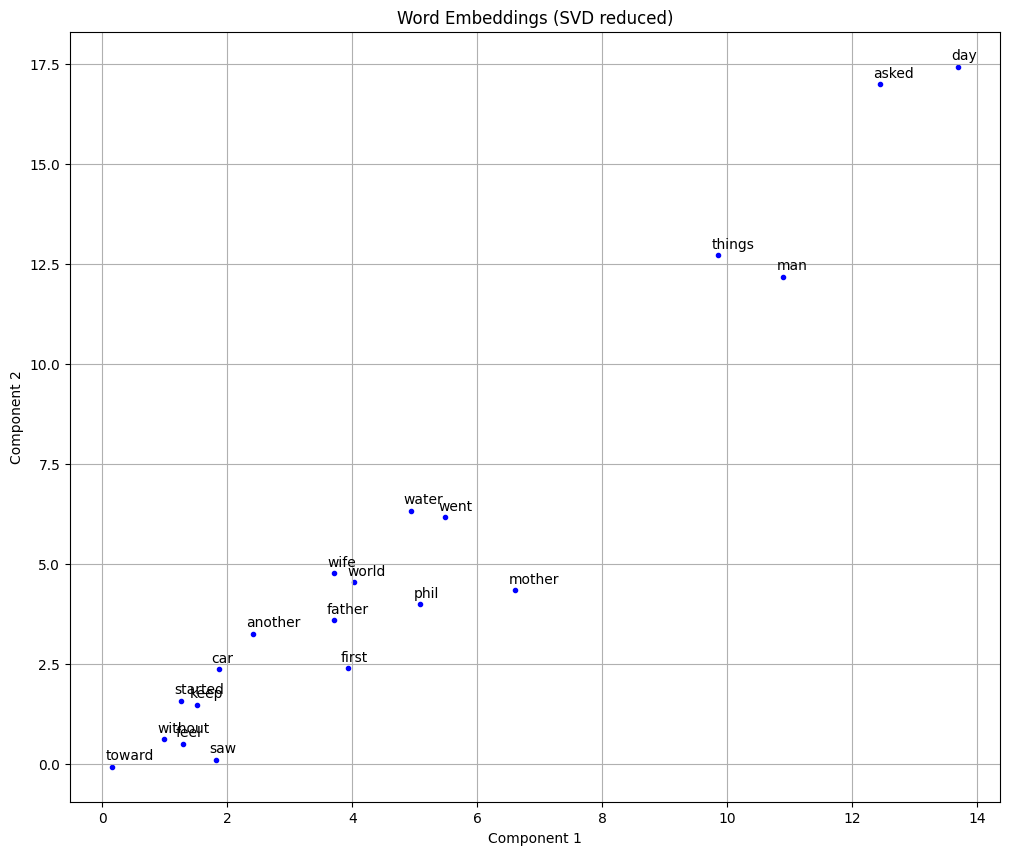

In [24]:
#CHANGE: added a call to create M_reduced which was previously not defined
M_reduced_brown= reduce_to_k_dim_fast(co_matrix_brown, 2) 

#note: word list needs to be adjusted to each new corpus with an explanation of why you choose to plot the words you do
#CHANGE: plotting all words but only annotating the 10 most frequent words
interesting_words_brown = sampled_words
#interesting_words_brown = ['accomplished', 'accident','back','wally', 'told','around', 'little', 'like', 'got','girl','boy','big','small','hate','love','dislike','woman','man','parent','mother','dad','family']
#interesting_words_brown = ['man', 'went', 'day', 'mother', 'first', 'asked', 'things', 'saw', 'another', 'phil', 'without', 'feel', 'world', 'keep', 'water', 'wife', 'started', 'father', 'car']
#plot_embeddings(M_reduced_brown, vocab=interesting_words_brown)

indices = [word_to_index_brown[word] for word in interesting_words_brown]
M_int_brown = M_reduced_brown[indices]
plot_embeddings(M_int_brown, vocab=interesting_words_brown)
plt.savefig(os.path.join("visualization", "brown_embeddings.png"), dpi=300, bbox_inches='tight')
plt.show()

2. Indian corpus

In [25]:
n =1 
# example using the ILM text
model_ilm = NGramModel(corpus_ilm, 2)
tokens_ilm = model_ilm.tokenize(drop_stopwords=True)
ngrams_ilm = model_ilm.generate_ngrams(tokens_ilm)
model_ilm.count_frequencies()
model_ilm.ngrams
ngrams_ilm=model_ilm.ngrams

In [26]:
#finding interesting words - printing 20 words every 10th word
# sum the rows to get total word frequencies
word_frequencies = np.array(co_matrix_ilm.sum(axis=1)).flatten()
sorted_indices = np.argsort(word_frequencies)[::-1] #sort
sorted_vocab = [vocab_ilm[i] for i in sorted_indices] #words
sampled_words = sorted_vocab[0:20] #slicing

print("20 words sampled (every 10th by frequency):")
print(sampled_words)
interesting_words_ilm = sampled_words



20 words sampled (every 10th by frequency):
['<s>', 'के', 'में', 'की', 'ने', 'है', 'को', 'से', 'पर', 'और', 'का', 'कि', 'हैं', 'विकेट', 'कहा', 'रन', 'कर', 'लिए', 'इस', 'एक']


In [27]:
#CHANGE: transalting the words for semantic analysis
from googletrans import Translator

def translate_words(words):
    translator = Translator()
    results = []
    for w in words:

        res = translator.translate(w, src='hi', dest='en')
        results.append(res.text)
    return results
translated_words = translate_words(interesting_words_ilm)

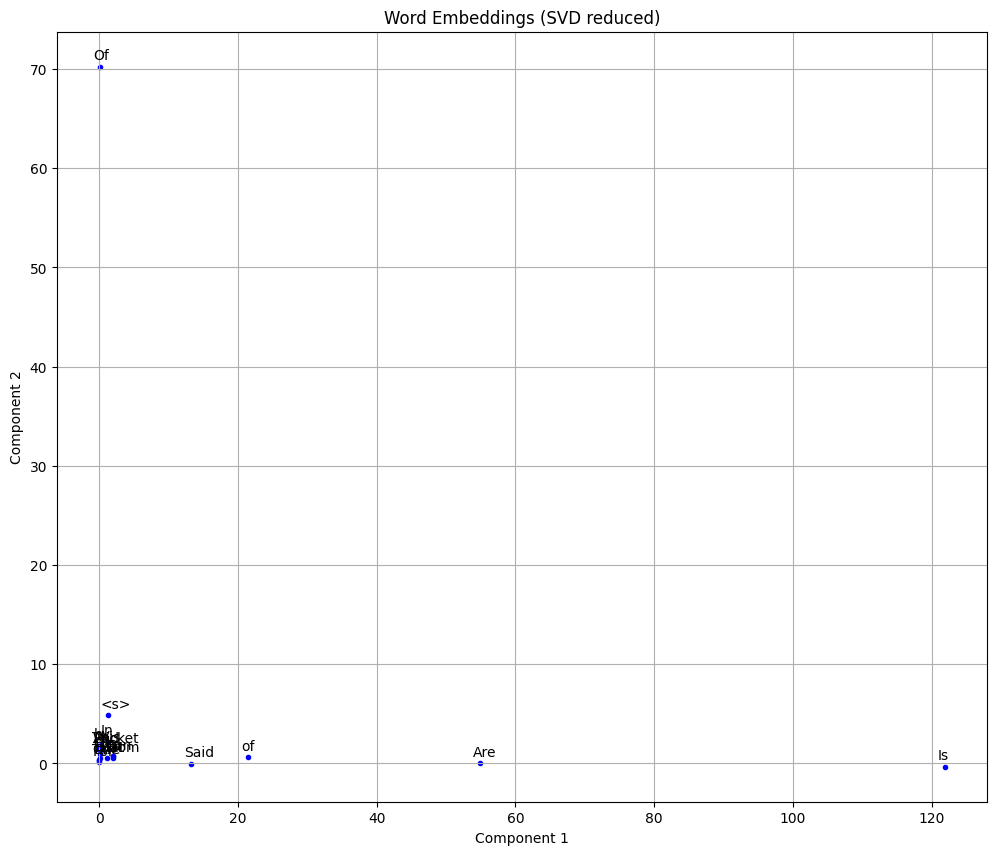

In [28]:

#CHANGE: added a call to create M_reduced which was previously not defined
M_reduced_ilm= reduce_to_k_dim_fast(co_matrix_ilm, 2) 

#note: word list needs to be adjusted to each new corpus with an explanation of why you choose to plot the words you do

indices_ilm = [word_to_index_ilm[word] for word in interesting_words_ilm]
M_int_ilm = M_reduced_ilm[indices_ilm]
plot_embeddings(M_int_ilm, vocab=translated_words)
plt.savefig(os.path.join("visualization", "ILM_embeddings.png"), dpi=300, bbox_inches='tight')
plt.show()

### Stopwords vs no stopwords

Here we extended our analysis by comparing the imapct of removing stpowords on the mebeddings on the brown corpus. Bron corpus was chosento increase the reliabitlity of the analysis, as we had a full list of stopwords in English.


20 first words sampled:
['<s>', 'said', 'would', 'one', 'could', 'like', 'back', 'time', 'little', 'even', 'man', 'didnt', 'thought', 'get', 'way', 'old', 'never', 'know', 'got', 'well']


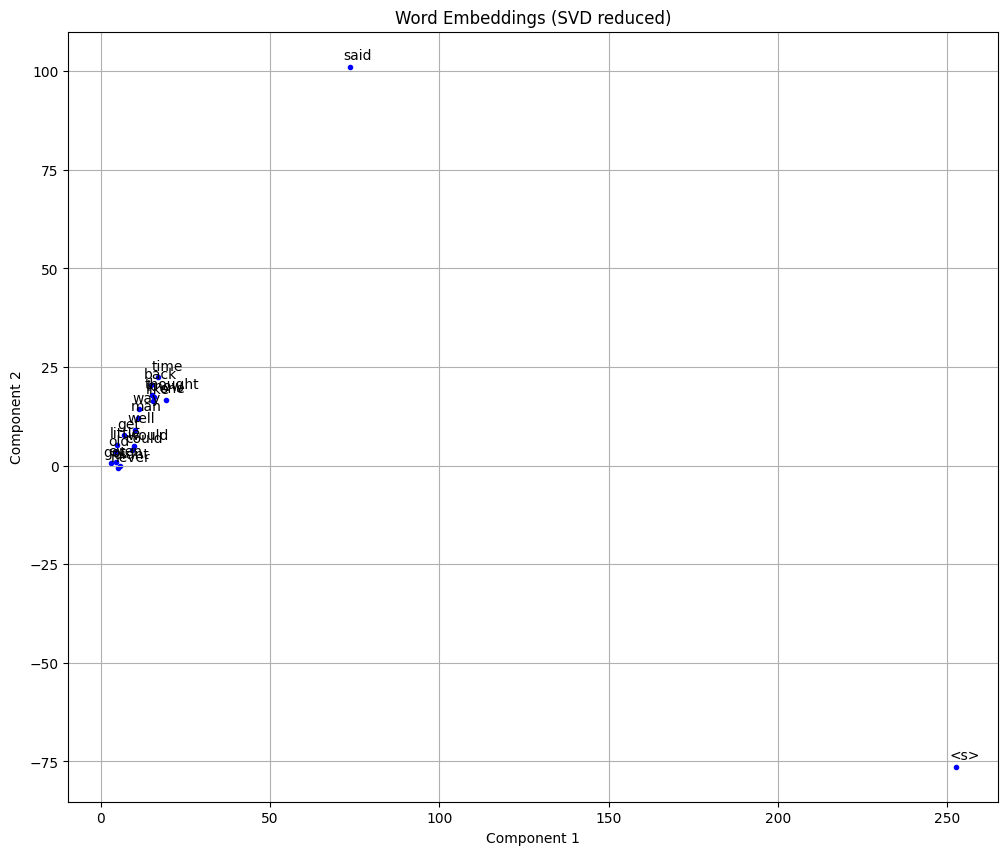

In [29]:
#CHANGE: checking most frequent words to plot 
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model_brown = NGramModel(corpus_brown, n)
tokens_brown = model_brown.tokenize(drop_stopwords=True)
ngrams_brown = model_brown.generate_ngrams(tokens_brown)
model_brown.count_frequencies()
model_brown.ngrams
ngrams_brown=model_brown.ngrams


#finding interesting words
# sum the rows to get total word frequencies
word_frequencies = np.array(co_matrix_brown.sum(axis=1)).flatten()
sorted_indices = np.argsort(word_frequencies)[::-1] #sort
sorted_vocab = [vocab_brown[i] for i in sorted_indices] #words
sampled_words = sorted_vocab[0:20] #slicing - first 20 words

print("20 first words sampled:")
print(sampled_words)

#CHANGE: added a call to create M_reduced which was previously not defined
M_reduced_brown= reduce_to_k_dim_fast(co_matrix_brown, 2) 

interesting_words_brown = sampled_words

indices = [word_to_index_brown[word] for word in interesting_words_brown]
M_int_brown = M_reduced_brown[indices]
plot_embeddings(M_int_brown, vocab=interesting_words_brown)
plt.savefig(os.path.join("visualization", "brown_embeddings_no_stopwords.png"), dpi=300, bbox_inches='tight')
plt.show()


20 first words sampled:
['<s>', 'the', 'and', 'to', 'a', 'of', 'in', 'was', 'he', 'i', 'it', 'that', 'had', 'she', 'her', 'his', 'you', 'with', 'for', 'at']


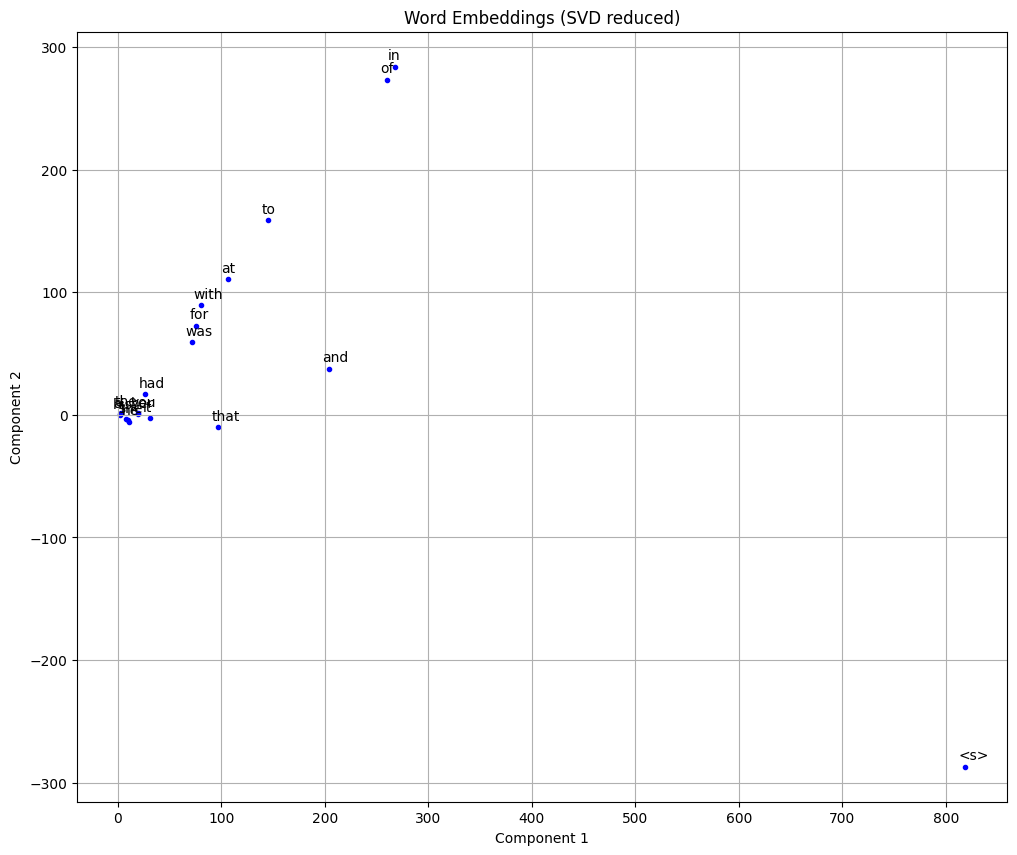

In [30]:
#CHANGE: checking most frequent words to plot 
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model_brown = NGramModel(corpus_brown, n)
tokens_brown = model_brown.tokenize(drop_stopwords=False)
ngrams_brown = model_brown.generate_ngrams(tokens_brown)
model_brown.count_frequencies()
model_brown.ngrams
ngrams_brown=model_brown.ngrams


vocab_brown = sorted(list(set(tokens_brown)))
vocab_size_brown = len(vocab_brown)
word_to_index_brown = {word: idx for idx, word in enumerate(vocab_brown)}
co_matrix_brown = create_co_matrix(ngrams_brown, len(vocab_brown), word_to_index_brown)
#finding interesting words
# sum the rows to get total word frequencies
word_frequencies = np.array(co_matrix_brown.sum(axis=1)).flatten()
sorted_indices = np.argsort(word_frequencies)[::-1] #sort
sorted_vocab = [vocab_brown[i] for i in sorted_indices] #words
sampled_words = sorted_vocab[0:20] #slicing - first 20 words

print("20 first words sampled:")
print(sampled_words)

#CHANGE: added a call to create M_reduced which was previously not defined
M_reduced_brown= reduce_to_k_dim_fast(co_matrix_brown, 2) 

interesting_words_brown = sampled_words

indices = [word_to_index_brown[word] for word in interesting_words_brown]
M_int_brown = M_reduced_brown[indices]
plot_embeddings(M_int_brown, vocab=interesting_words_brown)
plt.savefig(os.path.join("visualization", "brown_embeddings_with_stopwords.png"), dpi=300, bbox_inches='tight')
plt.show()


## Prediction-Based Word Vectors
In this section, we load pre-trained word vectors using the **GloVe** embeddings from the [Stanford NLP paper on GloVe](https://nlp.stanford.edu/pubs/glove.pdf). The pre-trained embeddings provide rich semantic information about words based on large text corpora, allowing us to represent words as vectors that capture their meaning and relationships.

Steps:
1. **Load GloVe Word Vectors**: We use the GloVe embeddings from the `glove-wiki-gigaword-200` model, which has 200-dimensional vectors for each word.
2. **Vocabulary Matching**: We map the words from our corpus to the GloVe vocabulary and extract the corresponding vectors.
3. **Dimensionality Reduction**: After obtaining the word vectors, we reduce the dimensionality to visualize the embeddings in 2D space, allowing us to explore word relationships visually.

This is an excellent opportunity to explore how pre-trained embeddings like GloVe can be used to improve downstream NLP tasks by providing richer word representations.

In [33]:
# Do not edit
import gensim.downloader as api
import numpy as np
wv_from_bin = api.load("glove-wiki-gigaword-200")
print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))

wv_words = list(wv_from_bin.index_to_key)
unique_tokens = set(tokens_glove_brown)
word2ind = {}
M = []
idx = 0
print('rendering M based on wv')
for w in wv_words:
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass

print('rendering M based on unique_tokens')
for w in unique_tokens:
    if w in wv_words:
        continue
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass
M = np.stack(M)
M_reduced = reduce_to_k_dim(M, k=2)

M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis]

Loaded vocab size 400000
rendering M based on wv
rendering M based on unique_tokens
First singular value: 1133.24
Second singular value: 479.35


### Compare plots
What stands out when comparing the two different ways of embedding using the given words?

(Use this to help answer the question in your assignment document).

['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s", 'for', '-', 'that', 'on', 'is', 'was', 'said', 'with', 'he', 'as', 'it', 'by', 'at', '(', ')', 'from', 'his', "''", '``', 'an', 'be', 'has', 'are', 'have', 'but', 'were', 'not', 'this', 'who', 'they', 'had', 'i', 'which', 'will', 'their', ':', 'or', 'its', 'one', 'after', 'new', 'been', 'also', 'we', 'would', 'two', 'more', "'", 'first', 'about', 'up', 'when', 'year', 'there', 'all', '--', 'out', 'she', 'other', 'people', "n't", 'her', 'percent', 'than', 'over', 'into', 'last', 'some', 'government', 'time', '$', 'you', 'years', 'if', 'no', 'world', 'can', 'three', 'do', ';', 'president', 'only', 'state', 'million', 'could', 'us', 'most', '_', 'against', 'u.s.', 'so', 'them', 'what', 'him', 'united', 'during', 'before', 'may', 'since', 'many', 'while', 'where', 'states', 'because', 'now', 'city', 'made', 'like', 'between', 'did', 'just', 'national', 'day', 'country', 'under', 'such', 'second', 'then', 'company', 'group', 'any', 

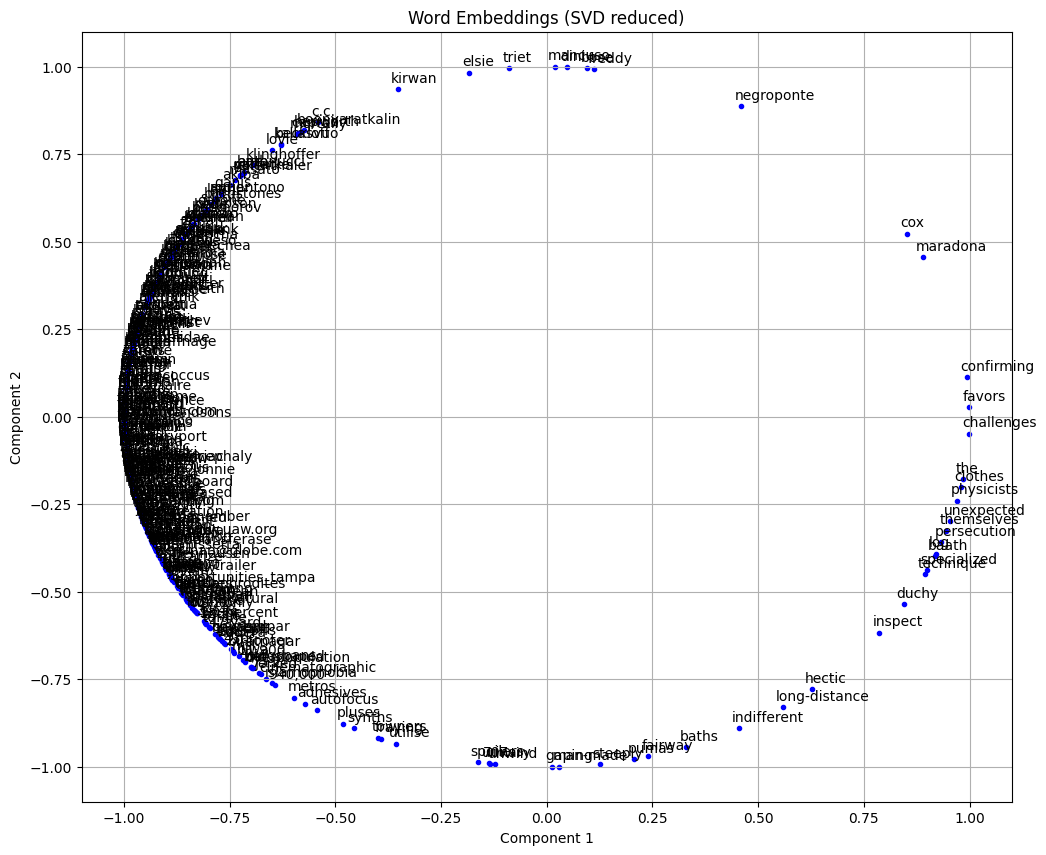

In [34]:
# CHANGE: creating a sorted list of words in M
sorted_tokens = sorted(word2ind.keys(), key=lambda w: word2ind[w])
print(sorted_tokens)

# change: avoid plotting all labels we specify only every 1000th as the computaitonal load was too big to plot all 
plot_embeddings(M_reduced_normalized[::1000], sorted_tokens[::1000])
#plot_embeddings(M_reduced_normalized[:1000], sorted_tokens[:100])
plt.savefig(os.path.join("visualization", "glove_embeddings"), dpi=300, bbox_inches='tight')
plt.show()

### Words with multiple meanings
Polysemes and homonyms are words that have more than one meaning (see [this wiki page](https://en.wikipedia.org/wiki/Polysemy) to learn more about the difference between polysemes and homonyms). Your task is to find a word with at least two different meanings such that the top-10 most similar words (according to cosine similarity) contain related words from both meanings.

For example:
- "leaves" has both the "go_away" and "a_structure_of_a_plant" meanings in the top 10.
- "scoop" has both "handed_waffle_cone" and "lowdown" meanings in the top 10.

You will probably need to try several polysemous or homonymic words before you find one.

Once you discover a word that fits this criterion, state the word and explain the multiple meanings that occur in the top 10. Reflect on why many of the polysemous or homonymic words you tried didn’t work (i.e., why the top-10 most similar words only contain one of the word's meanings).

**Note**: Use the `wv_from_bin.most_similar(word)` function to get the top 10 most similar words. This function ranks all other words in the vocabulary based on their cosine similarity to the given word. For further assistance, you can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html).

In [35]:
#CHANGE: added the printing

words = ['school', 'spring', 'home', 'bank', 'head']
for word in words:
    similar_words = wv_from_bin.most_similar(word, topn=10)
    print(f"top 10 most similar words to {word} are:")
    for w, score in similar_words:
        print(f"{w}:{score:.4f}")

top 10 most similar words to school are:
schools:0.8051
students:0.7750
college:0.7744
elementary:0.7544
education:0.6951
high:0.6917
student:0.6892
graduate:0.6870
teacher:0.6807
campus:0.6580
top 10 most similar words to spring are:
summer:0.8025
autumn:0.7511
winter:0.7316
fall:0.6583
beginning:0.6508
starting:0.6282
year:0.6142
start:0.5800
next:0.5771
during:0.5727
top 10 most similar words to home are:
where:0.6929
went:0.6613
in:0.6582
back:0.6407
came:0.6378
just:0.6367
their:0.6328
out:0.6307
,:0.6286
come:0.6280
top 10 most similar words to bank are:
banks:0.7626
banking:0.6819
central:0.6284
financial:0.6167
credit:0.6050
lending:0.5981
monetary:0.5963
bankers:0.5913
loans:0.5803
investment:0.5740
top 10 most similar words to head are:
heads:0.7669
headed:0.6344
chief:0.6314
body:0.6098
assistant:0.6064
director:0.6038
deputy:0.5836
hand:0.5738
left:0.5574
arm:0.5566


### Synonyms
When considering **Cosine Similarity**, it's often useful to think of **Cosine Distance**, which is simply 1 - Cosine Similarity.

Find three words \( (w_1, w_2, w_3) \) where:
- \(w_1\) and \(w_2\) are **synonyms**.
- \(w_1\) and \(w_3\) are **antonyms**.

However, you need to find a case where **Cosine Distance** \( (w_1, w_3) < \text{Cosine Distance} (w_1, w_2) \). In other words, the antonym is **closer** to the word than its synonym in the vector space.

For example, "happy" (\(w_1\)) may be closer to "sad" (\(w_3\)) than to "cheerful" (\(w_2\)), which is counter-intuitive since we expect synonyms to be closer than antonyms. 

Once you find such an example, provide a possible explanation for why this result may have occurred.

Use the `wv_from_bin.distance(w1, w2)` function to compute the cosine distance between two words. You can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for further assistance.







In [36]:
#CHANGE: added the triples


# word triples: word, synonym & antonym)
triples = [
    ("sad","unhappy","happy"),
    ("improve","better", "degrade"),
    ("wealthy", "rich", "poor"),
    ("love", "adore", "hate"),
    ("big", "large", "small"),
]

rows = []
for w1, w2, w3 in triples:
    distance_synonym  = wv_from_bin.distance(w1, w2)   # distance from word to synonym
    distance_antonym  = wv_from_bin.distance(w1, w3)   # distance from word to antonym
    rows.append({
        "w1"              : w1,
        "w2 (synonym)"    : w2,
        "w3 (antonym)"    : w3,
        "dist(w1, w2)"    : round(distance_synonym, 4),
        "dist(w1, w3)"    : round(distance_antonym, 4),
        "antonym_closer?" : distance_antonym < distance_synonym   #boolean for distance compariosn
    })

df = pd.DataFrame(rows)
display(df)

,w1,w2 (synonym),w3 (antonym),"dist(w1, w2)","dist(w1, w3)",antonym_closer?
0,sad,unhappy,happy,0.4684,0.4040,True
1,improve,better,degrade,0.2779,0.6873,False
2,wealthy,rich,poor,0.3827,0.5609,False
3,love,adore,hate,0.6330,0.4935,True
4,big,large,small,0.3340,0.3511,False


We suspect that certain words might be more similar to their antonyms than to their synonyms becuase they are often used to contrast each other. The words such as sad/happy and love/hate are constantly used together in the same sentences precisely because they are each other's opposites. For example in very common phrases, such as "a love-hate relationship" or "happy, not sad".  
Additionally, when looking at love and hate, they are popular everyday words of the same difficulty, meaning they will often be used close to each other is similar contexts. Whearas, adore is more sophisticated, formal word, which might not be used in the same texts as love, thus the the cosine distance between love and adore is longer than between love and hate.

On the other hand, for pairs like wealthy/rich and improve/better are of the same popularity, and tend to appear together often, thus their distance is small. Interestingly, the distance in 5th triples is almost indentical, as all three words (big,large, small) are common togther in everyday language.

This shows the limitation of statistical embeddings whcih cannot fully caputre the semantic similarity between certain words, unlike humans. 

### Analogies
Word vectors have demonstrated the ability to solve analogies based on their learned semantic relationships. For instance, consider the analogy: 

**"man : grandfather :: woman : x"** 

(Read: man is to grandfather as woman is to x). Using word vectors, we can find the word \(x\) that completes the analogy.

In the example provided, we use the `most_similar` function from the Gensim library. This function identifies words that are most similar to the words in the positive list and most dissimilar to those in the negative list. For analogy solving, it effectively computes:

\[ \text{word}(x) = \text{most similar to} (\text{woman} + \text{grandfather} - \text{man}) \]

The result is the word with the highest cosine similarity to the target vector. You can use this approach to explore various analogies and gain insights into the semantic structure of word vectors.

Refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for more details on the `most_similar` function and how word vectors handle analogy-solving tasks.

In [ ]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
print(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

[('grandmother', 0.7608445286750793), ('granddaughter', 0.7200808525085449), ('daughter', 0.7168302536010742), ('mother', 0.7151536345481873), ('niece', 0.7005682587623596), ('father', 0.6659887433052063), ('aunt', 0.6623409390449524), ('grandson', 0.6618767380714417), ('grandparents', 0.644661009311676), ('wife', 0.644535481929779)]


### Bias in word vectors


In [ ]:
print(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
print(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))
print()
print(wv_from_bin.most_similar(positive=['woman', 'hospital'], negative=['man']))

[('reputation', 0.5250176787376404), ('professions', 0.5178037881851196), ('skill', 0.49046966433525085), ('skills', 0.49005505442619324), ('ethic', 0.4897659420967102), ('business', 0.487585186958313), ('respected', 0.4859202802181244), ('practice', 0.4821045696735382), ('regarded', 0.4778572618961334), ('life', 0.4760662019252777)]

[('professions', 0.5957457423210144), ('practitioner', 0.4988412857055664), ('teaching', 0.48292139172554016), ('nursing', 0.48211807012557983), ('vocation', 0.4788965880870819), ('teacher', 0.47160351276397705), ('practicing', 0.46937811374664307), ('educator', 0.46524322032928467), ('physicians', 0.4628995656967163), ('professionals', 0.4601394236087799)]

[('hospitals', 0.6408509612083435), ('nurse', 0.6360577940940857), ('clinic', 0.6325280666351318), ('medical', 0.6236959099769592), ('nursing', 0.615903913974762), ('doctors', 0.5978248119354248), ('maternity', 0.580765426158905), ('nurses', 0.5688700079917908), ('psychiatric', 0.5618268847465515), ('

a. **Observation**: Consider the results of a word vector model when queried with analogies involving "man", "woman", and "profession". What are the top results returned by the model for each query?

In this call, we are looking for words most similar to man and profession but most dissimilar to 'woman'. The algorithm outputs the following list: [('reputation', 0.5250176787376404), ('professions', 0.5178037881851196), ('skill', 0.49046966433525085), ('skills', 0.49005505442619324), ('ethic', 0.4897659420967102), ('business', 0.487585186958313), ('respected', 0.4859202802181244), ('practice', 0.4821045696735382), ('regarded', 0.4778572618961334), ('life', 0.4760662019252777)].

The second call looking for most similar words to women and profession but furthest from a man outputs: [('professions', 0.5957457423210144), ('practitioner', 0.4988412857055664), ('teaching', 0.48292139172554016), ('nursing', 0.48211807012557983), ('vocation', 0.4788965880870819), ('teacher', 0.47160351276397705), ('practicing', 0.46937811374664307), ('educator', 0.46524322032928467), ('physicians', 0.4628995656967163), ('professionals', 0.4601394236087799)]

b. **Analysis**: Do you observe any gender biases in the results? For example, are certain professions more closely associated with "man" or "woman" based on the word vectors? Discuss how word embeddings might perpetuate societal biases present in the training data.

This small experiment shows that a male professional is associated with abstract qualities, whereas a professional woman is associated with concrete jobs. Specifically, the first output reputation, skill, business, respect and regard are all more closely associated to a working man than to a woman. It indicates a bias that is in the model, and which has been introduced by the training data, where a woman usually is not associated with a respected, skilled professional. The second call shows that professions most associated with a woman for the model are professional were stereotypically female qualities, such as nurturing and teaching.

Additional call, checking for a words most similar to woman and hospital (not a doctor to not bias with the non-gender English term for a doctor) and the furthers from a man, still outputs "hospitals, nurse, clinic, medical, nursing" before a 'doctor". This indicates that a woman is much more likely to be associated to be a nurse or simply be present in a clinical environment than be regarded as a doctor.

c. **Reflection**: How might such biases affect the fairness of machine learning models that use word embeddings? Suggest potential strategies for mitigating gender bias in word vector models.

This can have proofs consequences on the outputs of machine learning models, for example, AI is being increasingly used or is considered to be much more involved in recruitment processes. This can introduce bias, when looking for a most suited candidate for a stereotypically male-dominated position, such as a director, engineer or a doctor. Then the ML flag female candidates as less suited based on the training data. 
